# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


Global average life expectancy in 2007: 67.01
Region furthest below global average: Africa
Average deviation of this region: -12.2


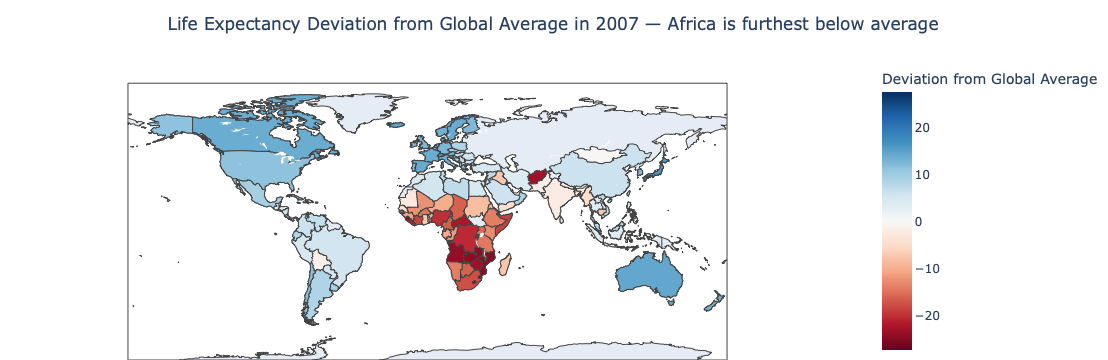

In [1]:
# Task 1
import pandas as pd
import plotly.express as px
import json
import urllib.request
 
df = px.data.gapminder()
 
# Filter year
gm_2007 = df[df["year"] == 2007].copy()
 
# global average
global_avg_life_exp = gm_2007["lifeExp"].mean()
 
# deviation from global average
gm_2007["lifeExp_deviation"] = gm_2007["lifeExp"] - global_avg_life_exp
 
region_deviation = gm_2007.groupby("continent")["lifeExp_deviation"].mean()
furthest_below_region = region_deviation.idxmin()
furthest_below_value = region_deviation.min()
 
print("Global average life expectancy in 2007:", round(global_avg_life_exp, 2))
print("Region furthest below global average:", furthest_below_region)
print("Average deviation of this region:", round(furthest_below_value, 2))
 
# choropleth map
fig = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="lifeExp_deviation",
    hover_name="country",
    hover_data={
        "lifeExp": ":.2f",
        "lifeExp_deviation": ":.2f",
        "continent": True,
        "iso_alpha": False
    },
    color_continuous_scale=px.colors.diverging.RdBu,
    color_continuous_midpoint=0,
    title=f"Life Expectancy Deviation from Global Average in 2007 — {furthest_below_region} is furthest below average",
    labels={
        "lifeExp_deviation": "Deviation from Global Average",
        "lifeExp": "Life Expectancy",
        "continent": "Region"
    }
)
 
# map layout
fig.update_geos(
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)
 
fig.update_layout(
    title_x=0.5,
    margin=dict(l=0, r=0, t=60, b=0)
)
 
fig.show()

## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:** *(URL or description)*

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**

*Your answer here*

**Colour scale chosen** (sequential or diverging) **and reason:**

*Your answer here*


AFG
{'name': 'Afghanistan'}


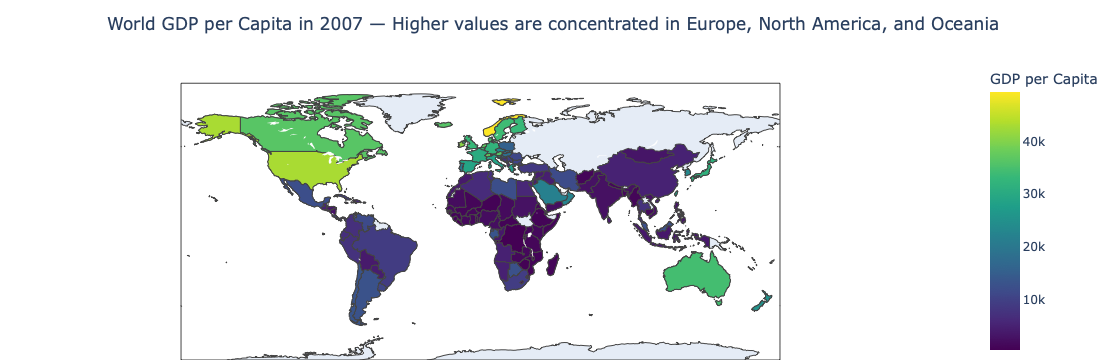

In [2]:
# Task 2
geojson_url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
 
with urllib.request.urlopen(geojson_url) as response:
    world_geojson = json.load(response)
 
#find the correct featureidkey
print(world_geojson["features"][0]["id"])
print(world_geojson["features"][0]["properties"])
 
df = px.data.gapminder()
 
# 4. Use only 2007 data
gm_2007 = df[df["year"] == 2007].copy()
 
# choropleth map
fig = px.choropleth(
    gm_2007,
    geojson=world_geojson,
    locations="iso_alpha",
    featureidkey="id",
    color="gdpPercap",
    hover_name="country",
    hover_data={
        "continent": True,
        "pop": ":,",
        "lifeExp": ":.2f",
        "gdpPercap": ":.2f",
        "iso_alpha": False
    },
    color_continuous_scale="Viridis",
    title="World GDP per Capita in 2007 — Higher values are concentrated in Europe, North America, and Oceania",
    labels={
        "gdpPercap": "GDP per Capita",
        "continent": "Region",
        "pop": "Population",
        "lifeExp": "Life Expectancy"
    }
)
 
# layout
fig.update_geos(
    showcoastlines=True,
    showland=True,
    fitbounds="locations"
)
 
fig.update_layout(
    title_x=0.5,
    margin=dict(l=0, r=0, t=60, b=0)
)
 
fig.show()